# SPRINT 11

Aquesta pràctica integra l'ús de Python amb les llibreries Pandas, Matplotlib, Seaborn o Plotly, així com la seva integració amb Power BI. Treballaràs tot el procés des de la connexió a MySQL, la creació de visualitzacions avançades en Python i finalment la incorporació d'aquestes visualitzacions a un informe dinàmic a Power BI.

## Nivell 1


### Exercici 1

Connecta Python amb MySQL Workbench i carrega les dades de la teva base de dades del Sprint 4 per utilitzar-les en tots els exercicis.

#### Importante:

Muy importante: Por motivos de seguridad, todos los datos de conexión los guardaré en un archivo .env que contendrá las contraseñas, usuarios, etc. Lo colocaré en la raíz del proyecto, pero no se subirá a GitHub gracias al archivo .gitignore. Es la forma segura de realizar este tipo de conexiones.

Para realizar el ejercicio 1, y en general para todo el tema de las conexiones a bases de datos, utilizaré la librería SQLAlchemy, ya que es una solución más utilizada actualmente y ofrece mayores ventajas si posteriormente quisiera conectarme a otras bases de datos.

In [2]:
# 1. Cargar las librerias necesarias

import os
import pandas as pd

from sqlalchemy import create_engine, text, inspect 
from sqlalchemy.exc import SQLAlchemyError
from dotenv import load_dotenv  # para las variables de entorno seguras

In [3]:
# REalizar la conexión segura

# leer y cargar variables del .env

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")   


# crear conexión con

try:

    engine = create_engine(
        f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

    with engine.connect() as connection:

        connection.execute(text("SELECT 1"))

    print("Conexión exitosa")

except SQLAlchemyError as e:

    print(f"Error de conexión: {e}")

Conexión exitosa


In [4]:
# Obtener las tablas de mySQL starmarketplace

inspector = inspect(engine)

tablas = inspector.get_table_names()

print(tablas)

['companies', 'credit_card_activated', 'credit_cards', 'products', 'transaction_product', 'transactions', 'users']


In [5]:
# importar las tablas de MySQL

dataframes = {}

for tabla in tablas:
    dataframes[tabla] = pd.read_sql(f"SELECT * FROM {tabla}", engine)

print(dataframes.keys())

dict_keys(['companies', 'credit_card_activated', 'credit_cards', 'products', 'transaction_product', 'transactions', 'users'])


In [6]:
for nombre, df in dataframes.items():
    print(f"{nombre}: {df.shape}")

companies: (100, 6)
credit_card_activated: (5000, 2)
credit_cards: (5000, 9)
products: (100, 6)
transaction_product: (253391, 3)
transactions: (100000, 10)
users: (5000, 11)


In [7]:
# cierro conexion, ya no necesito y libero recursos

engine.dispose()
print("Conexión creada")

Conexión creada


In [8]:
# saco los dataframes de las tablas del diccionario

df_companies = dataframes["companies"]
df_credit_card_activated = dataframes["credit_card_activated"]
df_credit_cards = dataframes["credit_cards"]
df_products = dataframes["products"]
df_transaction_product = dataframes["transaction_product"]
df_transactions = dataframes["transactions"]
df_users = dataframes["users"]

### Exercici 2

Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

Recorda: quan seleccionis les columnes, pensa sempre en el mètode que faràs servir i inclou les que calguin per a la funció de visualització que vulguis utilitzar.

- Una variable numèrica.
- Dues variables numèriques.
- Una variable categòrica.
- Una variable categòrica i una numèrica.
- Dues variables categòriques.
- Tres variables combinades.
- Crea un Pairplot.

In [9]:
# importar librerias de visualizacion matplotlib , seaborn y plotly

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# Visualización de companies. En una tabla de dimensiones y no tiene variables numéricas
# Elijo el campo de categoria "country" para contar cuantas companies hay en cada pais

df_companies["country"].value_counts()

country
Sweden            11
Netherlands       10
United States      9
United Kingdom     9
Italy              9
Germany            8
Belgium            8
Norway             7
Australia          6
New Zealand        6
Ireland            6
Canada             5
France             3
China              2
Spain              1
Name: count, dtype: int64

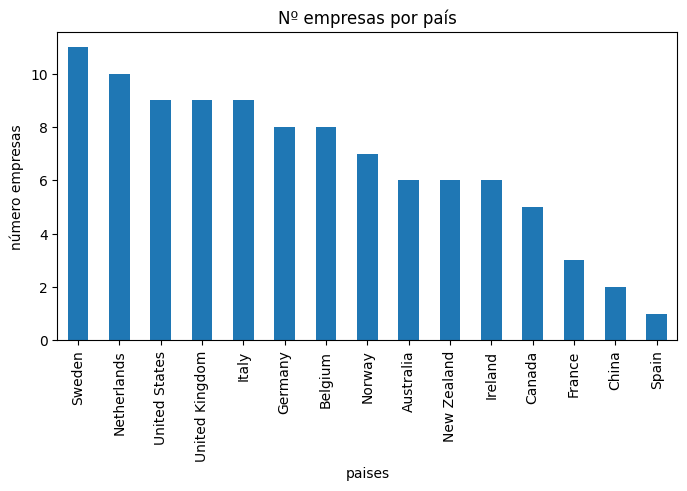

In [68]:
# Para una variable categorica hay varias opciones barras o treemap serian las más recomendables

plt.figure(figsize=(8,4), dpi=100)
df_companies["country"].value_counts().plot.bar()
plt.xlabel("paises") # definir el nombre del eje X
plt.ylabel("número empresas") # definir el nombre del eje Y
plt.title("Nº empresas por país");

In [ ]:
# df_credit_card_activated tiene una variable booleana (Categorica nominal) en este caso lo ideal será un pie sobre valores contados

df_credit_card_activated["activated"].value_counts()

activated
1    4995
0       5
Name: count, dtype: int64

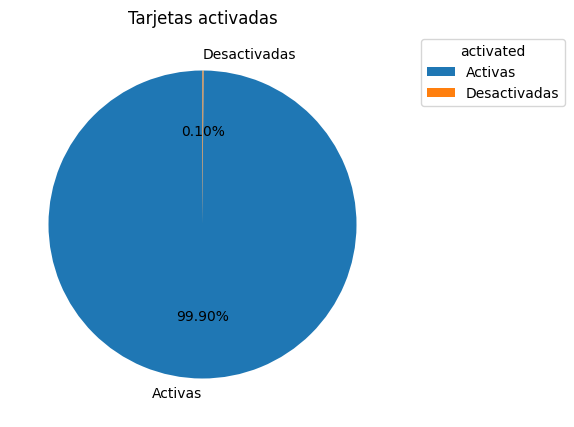

In [67]:

plt.figure(figsize=(5,5), dpi=100)
plt.title("Tarjetas activadas")
df_credit_card_activated["activated"].value_counts().plot.pie(
    labels=("Activas", "Desactivadas"), 
    autopct='%1.2f%%', 
    startangle = 90
    )
plt.legend(title="activated", bbox_to_anchor=(1.05,1));

In [ ]:
# Para df_credit_cards utilizare la expiring_date para realizar la visualización

df_credit_cards.groupby